# Browse Y Info SNPs
Downlaoded from ysnp.info in February 2026 by Eric Garcia

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import socket as socket
import os as os
import sys as sys
import h5py
import multiprocessing as mp

socket_name = socket.gethostname()
print(socket_name)

if socket_name.startswith("bionc") or socket_name.startswith("hpc"):
    print("Leipzig Cluster detected!")
    path = "/mnt/archgen/users/hringbauer/git/EPIDEMIC"

else: 
    raise RuntimeWarning("Not compatible machine. Check!!")

os.chdir(path)  # Set the right Path (in line with Atom default)
print(os.getcwd())
print(f"CPU Count: {mp.cpu_count()}")

hpc030
Leipzig Cluster detected!
/mnt/archgen/users/hringbauer/git/EPIDEMIC
CPU Count: 128


In [16]:
path_snps = "/mnt/archgen/users/eric_garcia/OYdb/merged_hg38_hg19_OY_SNP.csv"
df = pd.read_csv(path_snps)
print(f"Loaded {len(df)} OY SNPs")

Loaded 2930035 OY SNPs


### Make copy in Harald's Git folder

In [28]:
path_snps1 = "/mnt/archgen/users/hringbauer/git/y_chrom/data/OY/merged_hg38_hg19_OY_SNP.csv"
!cp $path_snps $path_snps1

### Scatter Plot of Positions

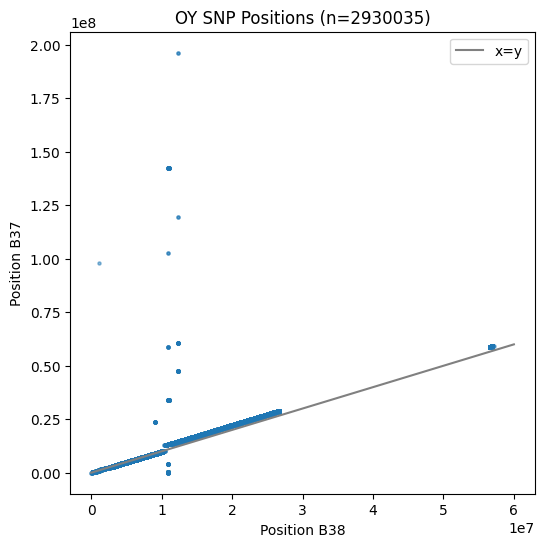

In [27]:
plt.figure(figsize=(6,6))
ax = plt.gca()
ax.scatter(df["Build38"], df["Build37"], s=5, alpha=0.5)
ax.set_xlabel("Position B38")
ax.set_ylabel("Position B37")
ax.set_title(f"OY SNP Positions (n={len(df)})")
ax.plot([0,6e7],[0,6e7], c="gray", label="x=y")
ax.legend(loc="upper right")
plt.show()

In [42]:
dfc = df["Build38"].value_counts()
dfc[dfc>1]

Build38
1           10
21023287     5
13398184     5
21027404     5
22209150     5
            ..
22266136     2
22266195     2
22264601     2
22264622     2
22265769     2
Name: count, Length: 190623, dtype: int64

In [46]:
df[df["Build38"]==22266136]

,Unnamed: 0,Build38,ANC,DER,SNP-ID,Build37
1814396,1814398,22266136,C,T,C326114,24412283.0
1814397,1814399,22266136,G,A,ZS4451,24412283.0


In [58]:
df.sort_values(by="Build38")[-50:]

,Unnamed: 0,Build38,ANC,DER,SNP-ID,Build37
2387214,2387216,61940468,G,A,KHU7649_CP086569.1,NaN
2387217,2387219,61941081,T,C,KHU1877_CP086569.1,NaN
2387227,2387229,61941972,G,A,KHU1592_CP086569.1,NaN
2387243,2387245,61943262,G,A,KHU1168_CP086569.1,NaN
2387272,2387274,61944936,T,C,KHU7724_CP086569.1,NaN
2387274,2387276,61945002,T,C,KHU1009_CP086569.1,NaN
2387531,2387533,61960020,G,C,A31471,NaN
2387974,2387976,61987388,G,A,KHU2413_CP086569.1,NaN
2387976,2387978,61987491,T,C,KHU7656_CP086569.1,NaN
2387990,2387992,61988080,A,T,KHU1839_CP086569.1,NaN


### 1) Check against reference genome

In [47]:
path_fasta = "/mnt/archgen/Reference_Genomes/Human/GRCh38/GRCh38.fa"

###[Optional] Test single position lookup

In [55]:
!samtools faidx $path_fasta chrY:22266136-22266136

>chrY:22266136-22266136
G


### 1b) Create Region file
Should be in this format:

chrY:2786855-2786855

chrY:593735-593735

In [66]:
def create_regions_fileY(positions=[], outpath="", sort=True, ylen=57227415):
    """Create Regions file for Y chromosome positions"""
    idx = positions<ylen
    print(f"Filtering to {np.sum(idx)}/{len(idx)} positions on actual Y coords.")
    positions = positions[idx]
    
    if sort:
        positions = sorted(set(positions)) # Sort First
    print(f"Writing regions file of {len(positions)} positions...")
    with open(outpath, "w") as f:
        for pos in positions:
            f.write(f"chrY:{pos}-{pos}\n")
    print(f"Finished writing regions file.")

def get_ref_df(output_file):
    """Return Dataframe with Positions and Ref alleles"""
    dft = pd.read_csv(output_file, header=None)
    ref = dft[1::2].values[:,0]
    pos = dft[::2][0].str.split("-").str[1].values.astype("int")
    assert(len(ref)==len(pos))
    df1 = pd.DataFrame({"pos":pos, "ref":ref})
    return df1

In [67]:
%%time
regions_file_path = "/mnt/archgen/users/hringbauer/git/y_chrom/data/OY/regions_file.txt"
create_regions_fileY(positions=df["Build38"].values,
                     outpath=regions_file_path, sort=True)

Filtering to 2929628/2930035 positions on actual Y coords.
Writing regions file of 2730487 positions...
Finished writing regions file.
CPU times: user 1.83 s, sys: 251 ms, total: 2.08 s
Wall time: 2.58 s


### Extract Reference Alleles

In [85]:
%%time
regions_file_path = "/mnt/archgen/users/hringbauer/git/y_chrom/data/OY/regions_file.txt"
output_file = "/mnt/archgen/users/hringbauer/git/y_chrom/data/OY/ref_file.txt"

!samtools faidx $path_fasta -r $regions_file_path > $output_file

CPU times: user 327 ms, sys: 128 ms, total: 454 ms
Wall time: 29.9 s


df1 = get_ref_df(output_file)

In [138]:
df1["ref"].value_counts()

ref
G    750504
C    743044
A    618009
T    614037
N      4893
Name: count, dtype: int64

### 1c) Compare Reference Alleles

In [142]:
dfm = pd.merge(df, df1, left_on="Build38", right_on="pos", how="left")

In [153]:
idx = dfm["ANC"]==dfm["ref"]
idx1 = dfm["DER"]==dfm["ref"]
idx_either = idx | idx1

In [155]:
print(f"Anc Allele matching reference: {np.sum(idx)}/{len(idx)}")
print(f"Der Allele matching reference: {np.sum(idx1)}/{len(idx1)}")
print(f"Either: {np.mean(idx_either):.4%}")

Anc Allele matching reference: 2910162/2930035
Der Allele matching reference: 7345/2930035
Either: 99.5697%


In [156]:
dfm1 = dfm[idx_either]

In [160]:
dfm1.to_csv("/mnt/archgen/users/hringbauer/git/y_chrom/data/OY/merged_hg38_hg19_OY_SNP_filtered.csv")

In [229]:
print(f"Saved {len(dfm1)} filtered SNPs")

Saved 2917426 filtered SNPs


In [175]:
dfm1[dfm1["SNP-ID"].str.contains("U152")]

,Unnamed: 0,Build38,ANC,DER,SNP-ID,Build37,pos,ref
464667,464669,13221267,C,T,"MF661383,PF6570,S28,TY199545,U152",15333149.0,13221267.0,T
1233328,1233330,18505918,A,G,HU152,20667804.0,18505918.0,A


### 1d) Check Table with Levels added
Eric did this via a script browsing the parents of each SNP node

In [233]:
df1 = pd.read_csv("/mnt/archgen/users/eric_garcia/data/merged_hg38_hg19_OY_SNP_filtered_levels.csv",
                 low_memory=False)
print(f"Loaded {len(df1)} SNPs with levels added")

Loaded 2917426 SNPs with levels added


In [244]:
dft = df1[~df1["pos"].isnull()].copy() # Filter NANs
dft["pos"] = dft["pos"].astype("int")

dft.drop(columns="Unnamed: 0", inplace=True)
dft = dft.rename(columns={'SNP-ID': 'Subgroup Name',})

In [247]:
### Save filtered version to Harald's Directory
dft.to_csv("/mnt/archgen/users/hringbauer/git/y_chrom/data/all_snps_filtered_levels.csv", index=False)

# 2) Load Levels

In [176]:
level_file = "/mnt/archgen/users/eric_garcia/data/derived_PTN209_ss.B0201.csv"

dfl = pd.read_csv(level_file)

In [197]:
dfc = dfl.groupby("Y-haplogroup").agg(
    n=('Y-haplogroup', 'count'),
    level=('Level', 'mean')).reset_index()

In [220]:
dfc.sort_values(by="level")[-50:-25]

,Y-haplogroup,n,level
127,R-BY203086,1,40.0
140,R-BY60213,1,40.0
132,R-BY3237,1,41.0
148,R-FGC59688,1,41.0
135,R-BY3490,2,41.0
77,J-FTC67462,1,42.0
131,R-BY2914,1,42.0
164,R-FTD25318,1,42.0
141,R-BY61788,1,42.0
151,R-FT185838,1,42.0


In [221]:
dfl[dfl["Y-haplogroup"]=="R-BY4233"]

,Unnamed: 0,SNP-ID,chrom,pos,ref,alt,A,C,G,T,ref#,alt#,Y-haplogroup,YFull translation,Level
6419,4604,A12312,Y,22087003,G,C,0,10,0,0,0,10,R-BY4233,NaN,44
6421,64,BY4233,Y,2870977,A,C,0,1,0,0,0,1,R-BY4233,NaN,44
6422,3626,BY4244,Y,17652884,C,T,0,0,0,13,0,13,R-BY4233,NaN,44


In [224]:
dfl[dfl["Y-haplogroup"]=="R-L2"]

,Unnamed: 0,SNP-ID,chrom,pos,ref,alt,A,C,G,T,ref#,alt#,Y-haplogroup,YFull translation,Level
6372,687,"L2,MF656651,S139",Y,5755550,C,T,0,0,0,11,0,11,R-L2,NaN,36


# PTN209 Y haplogroup call
There is a clear path to R-BY4233

In [183]:
dfl["Y-haplogroup"].value_counts()

Y-haplogroup
BT-M91              363
F-M89               178
A-L1090             168
R-M269               97
A-M31                63
R-Page29             58
A-V168               51
R-UTY2               46
P-P226               43
A-L1085              42
C-V9                 35
R-P297               28
A-AF6                28
F-Y60086             22
K-M9                 19
CT-M168              17
R-L761               12
A-Y8284              10
R-P25                10
P-M45                 9
A00-FGC26001          9
F-F21819              8
A-V221                6
O-F15948              6
N-SK1508              6
F-M427                5
IJK-L15               5
P-P284                5
R-L51                 5
O-F1234               4
R-DF90                4
CF-P143               4
R-L23                 3
O-F22068              3
R-L754                3
O-SK1608              3
R-BY4233              3
R-L151                3
F-MY1500              2
R-L389                2
O-F1100               2
R-B

In [178]:
dfl["Y-haplogroup"].str.split("-").str[0].value_counts()

Y-haplogroup
A        379
BT       365
R        336
F        215
P         58
C         40
O         31
K         21
CT        17
E         17
J         15
I         13
N          9
A00        9
IJK        5
CF         4
L          3
B          3
GHIJK      2
IJ         2
T          2
D          1
HIJK       1
S          1
M          1
G          1
Q          1
Name: count, dtype: int64

In [173]:
dfl[dfl["Y-haplogroup"].str.split("-").str[0] == "I"]

,Unnamed: 0,SNP-ID,chrom,pos,ref,alt,A,C,G,T,ref#,alt#,Y-haplogroup,YFull translation,Level
6173,4782,BY3424,Y,22464578,A,T,0,0,0,10,0,10,I-BY3419,NaN,24
6177,2119,BY86323,Y,13509479,C,T,0,0,0,1,0,1,I-BY67763,NaN,26
6228,1263,FTG32842,Y,8043374,G,A,1,0,0,0,0,1,I-FT19771,NaN,27
6330,6189,BY3095,Y,28799894,C,A,7,0,0,0,0,7,I-BY3095,NaN,29
6356,744,FTE77505,Y,5987704,C,T,0,0,0,1,0,1,I-FTE72226,NaN,32
6362,3931,Y3946,Y,18691057,G,A,10,0,0,0,0,10,I-Y3945,NaN,34
6363,5406,FT294227,Y,23625304,C,T,0,0,0,12,0,12,I-FT292902,NaN,34
6365,4405,Z26562,Y,21422802,T,C,0,5,0,0,0,5,I-Z26566,NaN,35
6369,6056,FTB84440,Y,28468365,C,T,0,0,0,1,0,1,I-BY64305,NaN,36
6374,3250,BY2835,Y,16453257,T,C,0,4,0,0,0,4,I-BY2834,NaN,36


# Area 51

In [248]:
df = pd.read_csv("/mnt/archgen/users/eric_garcia/data/branches_statitstics_PTN209_ss.B0201.csv")

In [261]:
df = df.sort_values(by="Level")
#dfd = df[df["Derived"]>0]
dfd = df[df["Derived"]>df["Ancestral"]]

In [263]:
dfd[-50:]

,Unnamed: 0,Branch,Level,Total_SNPs,Ancestral,Derived,Uncovered
3818,318,A-Y8284,5,10,0,10,0
3820,676,BT-M42,5,2,0,2,0
3837,677,BT-M91,6,418,55,363,0
3840,1737,CT-M168,6,19,2,17,0
3857,1448,C-V9,7,38,3,35,0
3864,1736,CF-P143,7,4,0,4,0
3866,9413,F-M89,8,185,7,178,0
3934,12484,GHIJK-YSC0001299,9,2,0,2,0
3945,12981,HIJK-M578,10,1,0,1,0
3950,9423,F-Y60086,10,32,10,22,0
